# **Fase 1: PyTorch e EDOs**
**Objetivo:** dominar o *framework* que será usado em PINNs e conectar os gradientes automáticos (*autograds*) com EDOs.

**Conceitos-chave:**

### Sumário

*Etapa 1.1 PyTorch básico*

*Etapa 1.2 `torch.autograd.grad` vs `.backward()`*

*Etapa 1.3 Aproximação de funções*

*Etapa 1.4 Proto-PINN: EDO sem chamar de PINN*

**Mini-projeto 1: Reconstrução de $H(z)$ a partir de dados de cronômetros cósmicos**

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

## 1. Gerando dados simulados

Antes de aplicar a análise em dados reais, iremos aplicar em dados simulados. Primeiro, vamos importar os dados reais.

In [2]:
# Arquivo de dados
filename = 'dados/Hz33Clocks.txt'
zi, hzi, shzi = np.genfromtxt(filename, comments='#', usecols=(0,1,2), unpack=True)

ndata = len(zi) # Número de dados

# Arquivo da covariância
filename = 'dados/data_MM20.dat'
zmod, imf, slib, sps, spsooo = np.genfromtxt(filename, comments='#', usecols=(0,1,2,3,4), unpack=True)

cov_mat_diag = np.zeros((ndata, ndata), dtype='float64')

for i in range(ndata):
    cov_mat_diag[i,i] = shzi[i]**2

imf_intp = np.interp(zi, zmod, imf)/100
spsooo_intp = np.interp(zi, zmod, spsooo)/100

cov_mat_imf = np.zeros((ndata, ndata), dtype='float64')
cov_mat_spsooo = np.zeros((ndata, ndata), dtype='float64')

for i in range(ndata):
    for j in range(ndata):
        cov_mat_imf[i,j] = hzi[i] * imf_intp[i] * hzi[j] * imf_intp[j]
        cov_mat_spsooo[i,j] = hzi[i] * spsooo_intp[i] * hzi[j] * spsooo_intp[j]

cov_mat = cov_mat_imf + cov_mat_spsooo + cov_mat_diag
inv_cov = np.linalg.inv(cov_mat)

Gerando os dados simulados.

In [3]:
def LCDM(z, parametros):
    H0, Om, Ol = parametros
    Ez2 = Om * (1 + z)**3 + Ol
    return H0 * np.sqrt(Ez2)

# Definição dos parâmetros do modelo
H0 = 68.0
Om = 0.34
Ol = 1 - Om

# Dados simulados
Hz_puro = LCDM(zi, [H0, Om, Ol])

# Adicionando ruídos
Hz_ruido = Hz_puro + np.random.normal(0, shzi, len(zi))

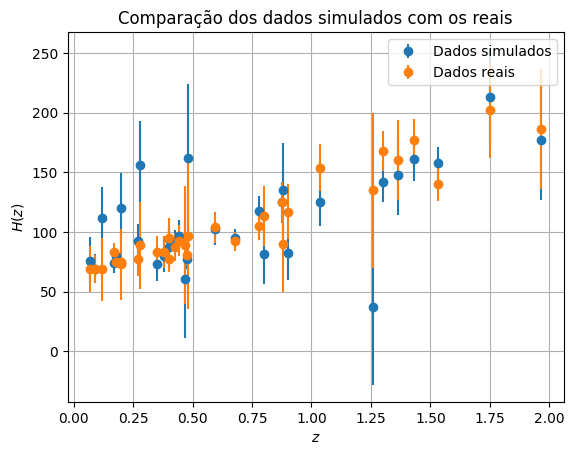

In [4]:
# Visualizando os dados sintéticos

plt.errorbar(zi, Hz_ruido, shzi, label='Dados simulados', fmt='o')
plt.errorbar(zi, hzi, shzi, label='Dados reais', fmt='o')
plt.title('Comparação dos dados simulados com os reais')
plt.xlabel('$z$')
plt.ylabel('$H(z)$')
plt.legend()
plt.grid()
plt.show()

In [5]:
# Normalizando os dados

z_max = np.max(zi)
Hz_max = np.max(Hz_ruido)

z_norm = (zi/z_max).reshape(-1, 1)
Hz_norm = (Hz_ruido/Hz_max).reshape(-1, 1)
err_Hz = (shzi/Hz_max).reshape(-1, 1)

Criando os tensores e inicializando os pesos e *bias*.

In [13]:
Hz_puro_max = np.max(Hz_puro)
Hz_puro_norm = (Hz_puro/Hz_puro_max).reshape(-1,1)

x = torch.tensor(z_norm, dtype=torch.float)
Y = torch.tensor(Hz_puro_norm, dtype=torch.float)
Y_err = torch.tensor(err_Hz, dtype=torch.float)

neuronios = 64

w1 = torch.randn((1, neuronios), requires_grad=True)
b1 = torch.randn(neuronios, requires_grad=True)

w2 = torch.randn((neuronios, 1), requires_grad=True)
b2 = torch.randn(1, requires_grad=True)

params = [w1, b1, w2, b2]

epocas = 25000
eta = 0.0001
optimizer = torch.optim.Adam(params, lr=eta)

def forward(x, params, activation=None):
    w1, b1, w2, b2 = params

    h1 = x @ w1 + b1

    if activation is not None:
        if activation == 'relu':
            z1 = torch.nn.functional.relu(h1)
        elif activation == 'tanh':
            z1 = torch.nn.functional.tanh(h1)

    y = z1 @ w2 + b2

    return y

def chi2(y, Y, sigma):
    return torch.sum(((y - Y)/sigma)**2)

for epoca in range(epocas):
    optimizer.zero_grad()
    y = forward(x, params, activation='relu')
    loss = chi2(y, Y, Y_err)
    loss.backward()
    optimizer.step()

    if (epoca+1)%(0.1*epocas) == 0 or epoca == 0:
        print(f'Época {epoca+1}:\n\n Loss = {loss}\n'+30*'-')

Época 1:

 Loss = 75230.2578125
------------------------------
Época 2500:

 Loss = 1.0208930969238281
------------------------------
Época 5000:

 Loss = 0.5643330812454224
------------------------------
Época 7500:

 Loss = 0.2786566913127899
------------------------------
Época 10000:

 Loss = 0.11650315672159195
------------------------------
Época 12500:

 Loss = 0.07258253544569016
------------------------------
Época 15000:

 Loss = 0.047579631209373474
------------------------------
Época 17500:

 Loss = 0.030451148748397827
------------------------------
Época 20000:

 Loss = 0.029969314113259315
------------------------------
Época 22500:

 Loss = 0.029427187517285347
------------------------------
Época 25000:

 Loss = 0.028919056057929993
------------------------------


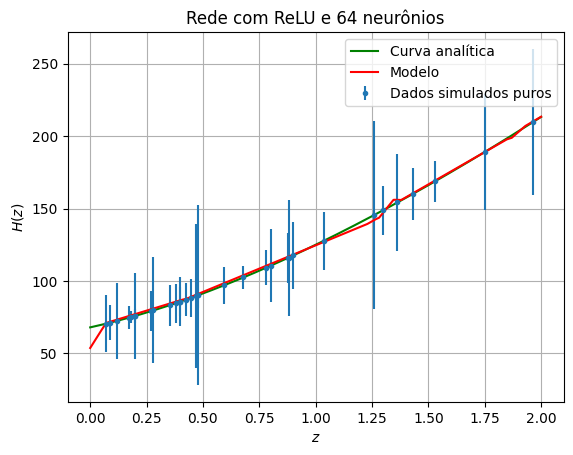

In [14]:
x = np.linspace(0, 2, 1000).reshape(-1, 1)
x_norm = x/np.max(x)
x_modelo = torch.tensor(x_norm, dtype=torch.float)
Y_modelo = LCDM(x, [H0, Om, Ol])
y_modelo = forward(x_modelo, params, activation='relu')*Hz_max

plt.errorbar(zi, Hz_puro, shzi, label='Dados simulados puros', fmt='.')
plt.plot(x, Y_modelo, label='Curva analítica', color='green')
plt.plot(x, y_modelo.detach().numpy(), label='Modelo', color='red')
plt.title('Rede com ReLU e 64 neurônios')
plt.xlabel('$z$')
plt.ylabel('$H(z)$')
plt.legend()
plt.grid()
plt.show()

Testando a rede com tanh.

In [17]:
x = torch.tensor(z_norm, dtype=torch.float)
Y = torch.tensor(Hz_norm, dtype=torch.float)
Y_err = torch.tensor(err_Hz, dtype=torch.float)

neuronios = 64

w1 = torch.randn((1, neuronios), requires_grad=True)
b1 = torch.randn(neuronios, requires_grad=True)

w2 = torch.randn((neuronios, 1), requires_grad=True)
b2 = torch.randn(1, requires_grad=True)

params = [w1, b1, w2, b2]

epocas = 50000
eta = 0.0001
optimizer = torch.optim.Adam(params, lr=eta)

def forward(x, params, activation=None):
    w1, b1, w2, b2 = params

    h1 = x @ w1 + b1

    if activation is not None:
        if activation == 'relu':
            z1 = torch.nn.functional.relu(h1)
        elif activation == 'tanh':
            z1 = torch.nn.functional.tanh(h1)

    y = z1 @ w2 + b2

    return y

def chi2(y, Y, sigma):
    return torch.sum(((y - Y)/sigma)**2)

for epoca in range(epocas):
    optimizer.zero_grad()
    y = forward(x, params, activation='tanh')
    loss = chi2(y, Y, Y_err)
    loss.backward()
    optimizer.step()

    if (epoca+1)%(0.1*epocas) == 0 or epoca == 0:
        print(f'Época {epoca+1}:\n\n Loss = {loss}\n'+30*'-')

Época 1:

 Loss = 290226.3125
------------------------------
Época 5000:

 Loss = 30.365520477294922
------------------------------
Época 10000:

 Loss = 25.88477897644043
------------------------------
Época 15000:

 Loss = 24.91128921508789
------------------------------
Época 20000:

 Loss = 24.558666229248047
------------------------------
Época 25000:

 Loss = 24.536815643310547
------------------------------
Época 30000:

 Loss = 24.53205108642578
------------------------------
Época 35000:

 Loss = 24.528682708740234
------------------------------
Época 40000:

 Loss = 24.525646209716797
------------------------------
Época 45000:

 Loss = 24.524301528930664
------------------------------
Época 50000:

 Loss = 24.520727157592773
------------------------------


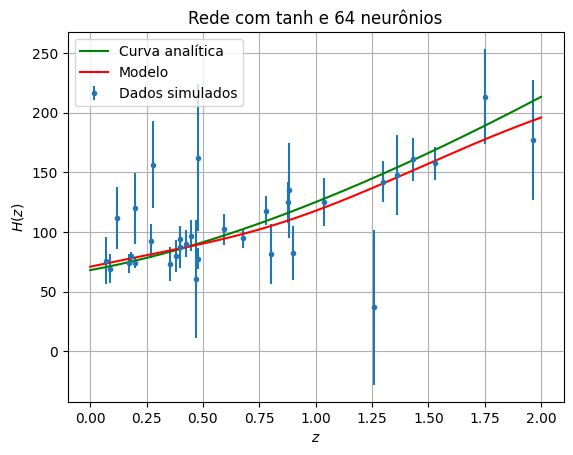

In [18]:
x = np.linspace(0, 2, 1000).reshape(-1, 1)
x_norm = x/np.max(x)
x_modelo = torch.tensor(x_norm, dtype=torch.float)
Y_modelo = LCDM(x, [H0, Om, Ol])
y_modelo = forward(x_modelo, params, activation='tanh')*Hz_max

plt.errorbar(zi, Hz_ruido, shzi, label='Dados simulados', fmt='.')
plt.plot(x, Y_modelo, label='Curva analítica', color='green')
plt.plot(x, y_modelo.detach().numpy(), label='Modelo', color='red')
plt.title('Rede com tanh e 64 neurônios')
plt.xlabel('$z$')
plt.ylabel('$H(z)$')
plt.legend()
plt.grid()
plt.show()